# M2 — Descriptive metrics of the Edmonton open-data catalogue

Core question 4 (`docs/SPEC_landscape.md`): how are size, update frequency, age and
column counts distributed? Metadata only.

**Input:** the M1c inventory, `data/processed/inventory/<date>.csv` (gitignored). It is
built from the *private* raw snapshot (`python -m src.inventory data/raw/private-snapshots/<date>`),
because the licence classifier reads descriptions. This notebook shows no descriptions.

**Not here yet:** dataset *size* (row counts need the per-asset column-statistics pull,
still undecided in `TODO.md`) and change over time (needs a second snapshot; the next
is due 2026-10-09).

Two counting views throughout, because 119 yearly/per-site series make up 620 of the
1421 real datasets (Speed Check Sign alone is 309):
- **all members** — every real dataset;
- **series once** — each series collapsed to one unit (920 units).

In [1]:
import json, os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INV_DIR = ROOT / "data/processed/inventory"
SNAP = os.environ.get("SNAPSHOT") or sorted(p.stem for p in INV_DIR.glob("*.csv"))[-1]

inv = pd.read_csv(INV_DIR / f"{SNAP}.csv")
manifest = json.loads((ROOT / f"data/snapshots/{SNAP}/manifest.json").read_text())
AS_OF = pd.Timestamp(manifest["reduced_from"]["retrieved_started_utc"])
for col in ["created_at", "data_updated_at", "metadata_updated_at"]:
    inv[col] = pd.to_datetime(inv[col], utc=True)

print(f"snapshot {SNAP}, retrieved {AS_OF:%Y-%m-%d %H:%M} UTC, {len(inv)} assets")

snapshot 2026-10-02, retrieved 2026-10-02 04:31 UTC, 2088 assets


In [2]:
# Palette: dataviz skill reference instance (light surface).
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "figure.dpi": 110,
})

def hbar(series, title, xlabel, color=BLUE, ax=None, fmt="{:,.0f}"):
    """Horizontal bars, largest on top, every bar direct-labelled."""
    s = series[::-1]
    ax = ax or plt.subplots(figsize=(8, 0.32 * len(s) + 1))[1]
    ax.barh([str(k) if len(str(k)) <= 45 else str(k)[:44] + "…" for k in s.index], s.values, color=color, height=0.7, edgecolor=SURFACE, linewidth=2)
    ax.grid(axis="y", visible=False)
    for y, v in enumerate(s.values):
        ax.text(v, y, " " + fmt.format(v), va="center", color=INK2, fontsize=9)
    ax.set_title(title); ax.set_xlabel(xlabel)
    ax.margins(x=0.12)
    return ax

## 1. Composition

Every asset has one role (M1c). Only `candidate` rows — Discovery type `dataset` with no
parent — are real datasets; the rest are views, charts, maps and stories built on them,
or non-tabular items.

In [3]:
comp = (inv.groupby(["role", "type"]).size().rename("assets").reset_index()
          .sort_values(["role", "assets"], ascending=[True, False]))
display(comp.set_index(["role", "type"]))

real = inv[inv.role == "candidate"].copy()
real["unit"] = real.series_key.fillna(real.id)
print(f"real datasets: {len(real)}  |  series once: {real.unit.nunique()}  |  "
      f"series: {real.series_key.nunique()} covering {real.series_key.notna().sum()} datasets")

assets
role        type            
candidate   dataset     1421
derived     map          279
            chart        179
            filter       108
            story         39
            calendar       1
non_tabular story         22
            href          21
            file          18

real datasets: 1421  |  series once: 920  |  series: 119 covering 620 datasets


In [4]:
# One row per unit. A series takes its earliest creation, its latest data update,
# its median column count and its most common value for each categorical field.
mode = lambda s: s.mode().iloc[0] if s.notna().any() else np.nan
units = real.groupby("unit").agg(
    name=("name", "first"), category=("category", mode), n_members=("id", "size"),
    created_at=("created_at", "min"), data_updated_at=("data_updated_at", "max"),
    n_columns=("n_columns", "median"), update_frequency=("update_frequency", mode),
    automated_or_manual=("automated_or_manual", mode), licence_class=("licence_class", mode),
)
assert len(units) == real.unit.nunique()

top = real.series_key.value_counts().head(8)
display(top.rename("members").to_frame())

,members
series_key,
Vehicle Speed|speed check sign - dfs#,309
City Administration|# requests (#),7
Surveys|# climate perception survey,6
City Administration|#-# council and committee meetings - agenda items,5
Thematic Features|orthophoto repository #,5
Surveys|# call centre satisfaction survey - #,5
Surveys|# climate perception survey codebook,5
City Administration|#-# council and committee meetings - voting record,5


## 2. Categories

The portal's own categories. Three of them (Surveys, Vehicle Speed, Census) are mostly
series members; collapsing series changes the picture of what the catalogue is "about".

38 categories; 24 more not shown (106 datasets); (none) = no category set


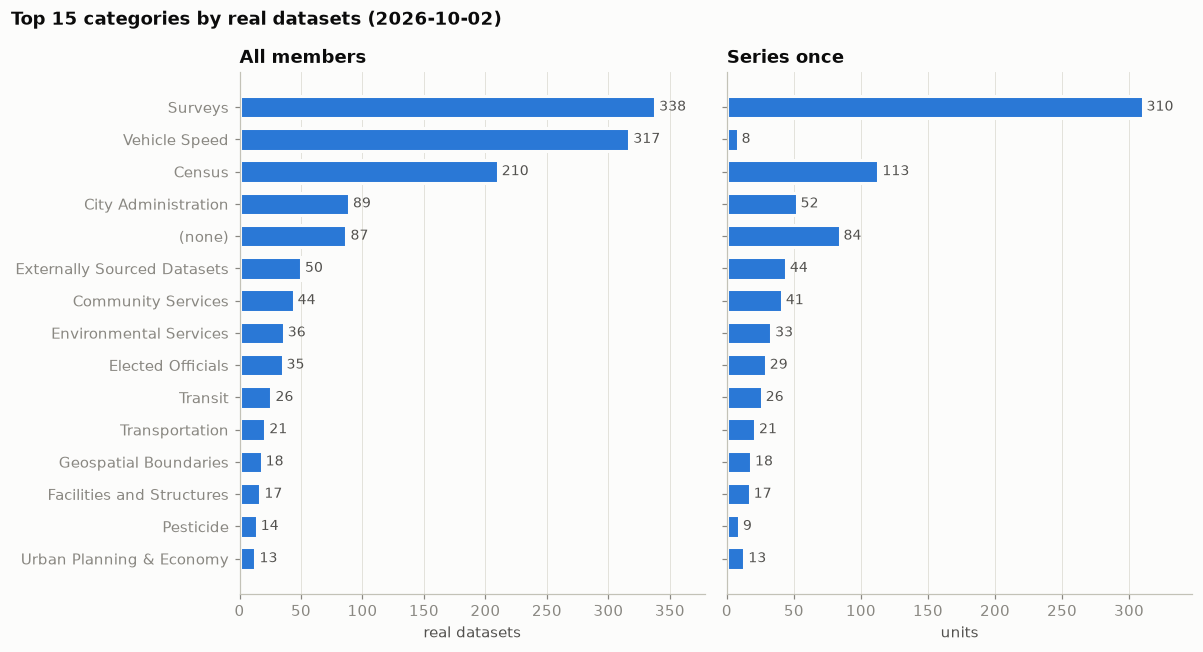

In [5]:
cat_all = real.category.fillna("(none)").value_counts()
cat_once = units.category.fillna("(none)").value_counts()
order = cat_all.head(15).index

fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)
hbar(cat_all[order], "All members", "real datasets", ax=axes[0])
hbar(cat_once.reindex(order).fillna(0), "Series once", "units", ax=axes[1])
axes[1].tick_params(labelleft=False)
fig.suptitle(f"Top 15 categories by real datasets ({SNAP})", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
print(f"{real.category.nunique()} categories; {cat_all.size - 15} more not shown "
      f"({cat_all.iloc[15:].sum()} datasets); (none) = no category set")

## 3. Age

When datasets were first published (`created_at`) and when their data last changed
(`data_updated_at`), counted with series once.

median age 8.6 y; median time since data update 5.7 y
data updated within 30 days: 196 of 920 units; not for 5+ years: 525


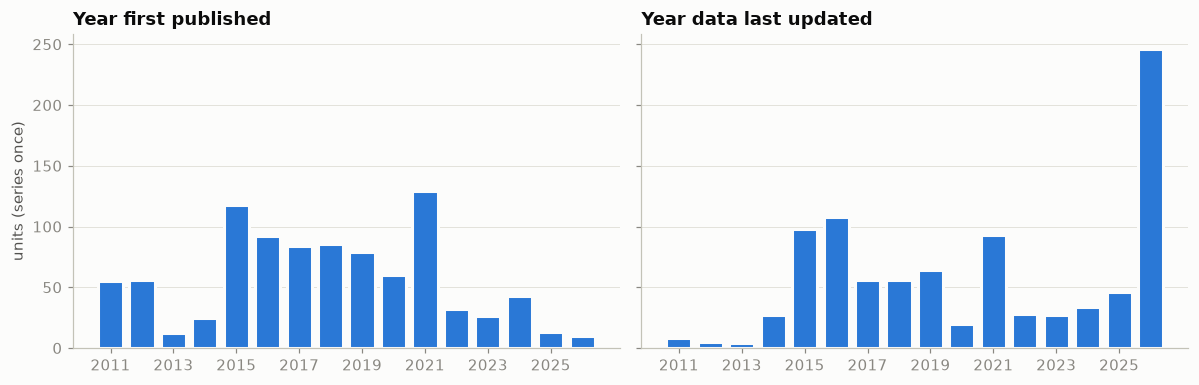

In [6]:
created = units.created_at.dt.year.value_counts().sort_index()
updated = units.data_updated_at.dt.year.value_counts().sort_index()
years = range(min(created.index.min(), updated.index.min()), AS_OF.year + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, s, title, c in [(axes[0], created, "Year first published", BLUE),
                        (axes[1], updated, "Year data last updated", BLUE)]:
    s = s.reindex(years, fill_value=0)
    ax.bar(s.index, s.values, color=c, width=0.8, edgecolor=SURFACE, linewidth=2)
    ax.set_title(title); ax.grid(axis="x", visible=False)
    ax.set_xticks(list(years)[::2])
axes[0].set_ylabel("units (series once)")
fig.tight_layout()

age_y = (AS_OF - units.created_at).dt.days / 365.25
stale_y = (AS_OF - units.data_updated_at).dt.days / 365.25
print(f"median age {age_y.median():.1f} y; median time since data update {stale_y.median():.1f} y")
print(f"data updated within 30 days: {(stale_y <= 30/365.25).sum()} of {len(units)} units; "
      f"not for 5+ years: {(stale_y >= 5).sum()}")

## 4. Claimed vs actual update frequency

The publisher's `Update Frequency` field against how recently `data_updated_at` moved.
A dataset is **on schedule** if its data changed within a generous window for its
claimed frequency (about twice the nominal interval). One snapshot can only show
recency, not regularity; a weekly series of snapshots will.

Caveat: `data_updated_at` moves when Socrata re-ingests, which may happen without any
change in the rows. Separating real change from refresh needs row-count fingerprints
(the undecided column-statistics pull).

In [7]:
WINDOW_DAYS = {"Hourly": 3, "Near Real-Time": 3, "X times per day": 3, "Daily": 3,
               "Weekly": 14, "Bi-Weekly": 28, "Monthly": 62, "Quarterly": 184,
               "Annually": 730}
NO_SCHEDULE = ["Not Updated (Historical Only)", "When Necessary"]

real["days_since_update"] = (AS_OF - real.data_updated_at).dt.days
freq = real.update_frequency.fillna("(not set)")
real["window"] = freq.map(WINDOW_DAYS)
real["on_schedule"] = real.days_since_update <= real.window

sched = real[real.window.notna()]
tab = (sched.groupby("update_frequency")
           .agg(datasets=("id", "size"), on_schedule=("on_schedule", "sum"),
                median_days_since=("days_since_update", "median"))
           .assign(share=lambda t: t.on_schedule / t.datasets)
           .reindex([k for k in WINDOW_DAYS if k in sched.update_frequency.values]))
tab.insert(0, "window_days", [WINDOW_DAYS[k] for k in tab.index])
display(tab.style.format({"share": "{:.0%}", "median_days_since": "{:.0f}"}))

late = len(sched) - sched.on_schedule.sum()
print(f"{len(sched)} datasets claim a schedule; {sched.on_schedule.sum()} on schedule, {late} behind")

,window_days,datasets,on_schedule,median_days_since,share
update_frequency,,,,,
Hourly,3,7,7,0,100%
Near Real-Time,3,5,4,0,80%
X times per day,3,11,8,0,73%
Daily,3,83,77,0,93%
Weekly,14,319,295,3,92%
Bi-Weekly,28,2,2,3,100%
Monthly,62,43,25,3,58%
Quarterly,184,8,6,48,75%
Annually,730,56,31,594,55%


534 datasets claim a schedule; 455 on schedule, 79 behind


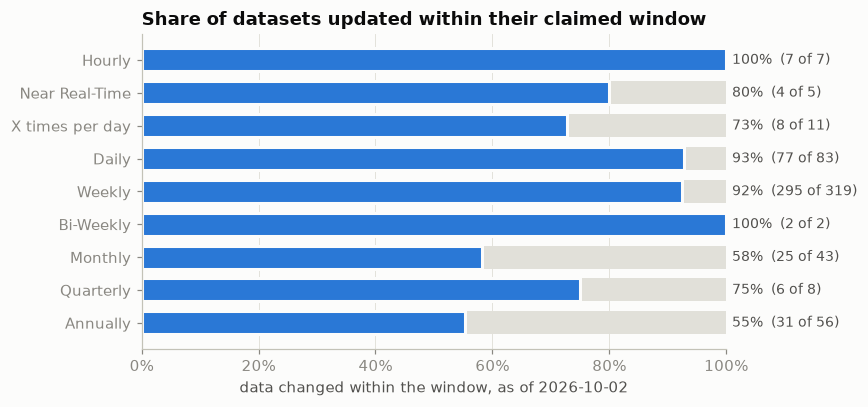

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.8))
s = tab.share[::-1]
ax.barh(s.index, 1, color=GRID, height=0.7)
ax.barh(s.index, s.values, color=BLUE, height=0.7, edgecolor=SURFACE, linewidth=2)
for y, (k, v) in enumerate(s.items()):
    ax.text(1.01, y, f"{v:.0%}  ({tab.on_schedule[k]:,} of {tab.datasets[k]:,})",
            va="center", color=INK2, fontsize=9)
ax.set_xlim(0, 1); ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.grid(axis="y", visible=False)
ax.set_title("Share of datasets updated within their claimed window")
ax.set_xlabel(f"data changed within the window, as of {AS_OF:%Y-%m-%d}")
fig.tight_layout()

In [9]:
# The two no-schedule claims, and datasets with no claim at all.
rest = real[real.window.isna()].assign(freq=freq)
bins = [-1, 30, 365, 5 * 365, 100 * 365]
labels = ["≤ 30 d", "31 d – 1 y", "1–5 y", "> 5 y"]
rest["since"] = pd.cut(rest.days_since_update, bins, labels=labels)
display(pd.crosstab(rest.freq, rest.since, margins=True, margins_name="total"))

hist_live = rest[(rest.freq == NO_SCHEDULE[0]) & (rest.days_since_update <= 30)]
print(f"'{NO_SCHEDULE[0]}' but data changed in the last 30 days: {len(hist_live)}")
display(hist_live[["id", "name", "category", "data_updated_at"]]
        .sort_values("data_updated_at", ascending=False).head(10))

since,≤ 30 d,31 d – 1 y,1–5 y,> 5 y,total
freq,,,,,
(not set),4,3,8,20,35
Not Updated (Historical Only),3,37,120,595,755
When Necessary,11,23,20,43,97
total,18,63,148,658,887


'Not Updated (Historical Only)' but data changed in the last 30 days: 3


,id,name,category,data_updated_at
1087,huhs-auh6,2017-2021 Council And Committee Meetings - Vot...,City Administration,2026-10-01 10:29:51+00:00
1030,h26g-8g9s,2021 Edmonton Election - Third Party Advertisers,Elected Officials,2026-10-01 09:21:43+00:00
515,9j6k-uzig,Deprecated - ETS - Bus Stops by Landmarks,Transit,2026-09-28 08:33:02+00:00


In [10]:
# Does 'Automated or Manual' line up with recent updates?
real["updated_14d"] = real.days_since_update <= 14
display(pd.crosstab(real.automated_or_manual.fillna("(not set)"), real.updated_14d,
                    margins=True, margins_name="total")
          .rename(columns={True: "data changed ≤ 14 d", False: "older"}))
stale_auto = real[(real.automated_or_manual == "Automated") & ~real.updated_14d]
print("Automated but no data change in 14 days, by claimed frequency:")
display(stale_auto.update_frequency.fillna("(not set)").value_counts().rename("datasets").to_frame())

updated_14d,older,data changed ≤ 14 d,total
automated_or_manual,,,
(not set),55,5,60
Automated,181,424,605
Manual,746,10,756
total,982,439,1421


Automated but no data change in 14 days, by claimed frequency:


,datasets
update_frequency,
Not Updated (Historical Only),107
Weekly,21
When Necessary,18
Monthly,17
Annually,5
Daily,4
X times per day,3
Quarterly,3
(not set),2


## 5. Column counts

Columns per dataset — the only size proxy without row counts. Series once uses each
series' median.

x-axis cut at 120; 8 units wider (listed below)
{'count': 920.0, 'mean': 22.9, 'std': 23.2, 'min': 1.0, '25%': 7.0, '50%': 17.0, '75%': 31.0, 'max': 222.0}


,units,median,max
category,,,
Surveys,310,36.0,222.0
Indoor Recreation,8,25.5,89.0
Vehicle Speed,8,22.5,70.0
Urban Planning & Economy,13,22.0,38.0
Schools,5,21.0,29.0
Transportation,21,20.0,48.0
Facilities and Structures,17,19.0,38.0
Environmental Services,33,18.0,70.0
Monitoring and Data Collection,7,17.0,30.0


,id,name,category,n_columns
1319,mecc-xmaa,2024 Climate Perception Survey,Surveys,239
1229,k2sr-dv2a,2023 Climate Perception Survey,Surveys,234
1739,tezb-wttq,Employment Engagement Survey 2018 Department/B...,Surveys,222
1586,r8it-8s85,Employment Engagement Survey 2018 Departmental...,Surveys,221
1970,xgj5-h4je,2025 Climate Perception Survey,Surveys,206
1710,t3j6-shpq,2022 Climate Perception Survey,Surveys,191
1335,mkk4-jicq,2021 Climate Perception Survey,Surveys,182
453,8j4x-ant3,Seniors Needs Assessment Survey - 2015,Surveys,159
1892,w4bx-p3t9,2020 Climate Perception Survey,Surveys,144
527,9r7c-qftq,E-scooters - December 2020 - Edmonton Insight ...,Surveys,141


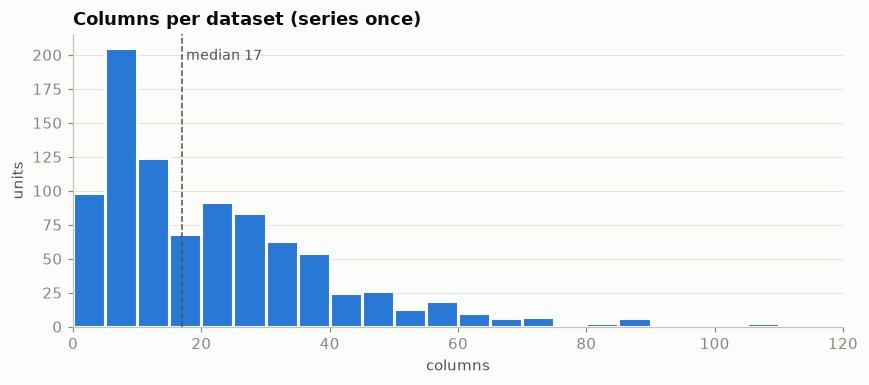

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.6))
bins = np.arange(0, units.n_columns.max() + 5, 5)
ax.hist(units.n_columns, bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=2)
ax.set_title("Columns per dataset (series once)")
ax.set_xlabel("columns"); ax.set_ylabel("units"); ax.grid(axis="x", visible=False)
med = units.n_columns.median()
ax.axvline(med, color=INK2, linewidth=1, linestyle="--")
ax.text(med, ax.get_ylim()[1] * 0.95, f" median {med:.0f}", color=INK2, fontsize=9, va="top")
cap = 120
ax.set_xlim(0, cap)
fig.tight_layout()
print(f"x-axis cut at {cap}; {(units.n_columns > cap).sum()} units wider (listed below)")

print(units.n_columns.describe().round(1).to_dict())
by_cat = (units.assign(category=units.category.fillna("(none)"))
               .groupby("category").n_columns.agg(["size", "median", "max"])
               .query("size >= 5").sort_values("median", ascending=False))
display(by_cat.rename(columns={"size": "units"}))
display(real.nlargest(10, "n_columns")[["id", "name", "category", "n_columns"]])

## 6. Licence and attribution

Licence class from M1c (`src/inventory.py`): City, third-party, or unknown (no
attribution and no `Internal or External` field). Third-party datasets need their own
attribution line when published (M5).

,all members,series once
licence_class,,
city,1235,755
third_party,132,118
unknown,54,47


38 distinct attribution values; licence field: {'See Terms of Use': 1294, '(none)': 124, 'Canada Open Government Licence': 3}

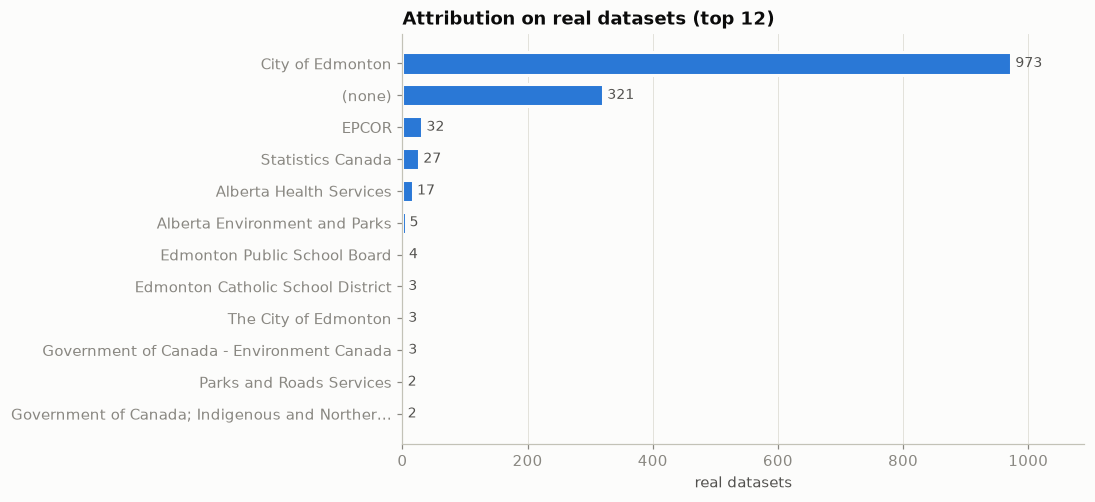

In [12]:
lc = pd.DataFrame({"all members": real.licence_class.value_counts(),
                   "series once": units.licence_class.value_counts()})
display(lc)
attr = real.attribution.fillna("(none)").value_counts()
hbar(attr.head(12), "Attribution on real datasets (top 12)", "real datasets")
# Spelling variants ("City of Edmonton" / "The City of Edmonton") are left as published.
print(f"{attr.size} distinct attribution values; licence field: "
      f"{real.licence_field.fillna('(none)').value_counts().to_dict()}")

## 7. Metadata completeness

How often the publisher's custom fields are filled on real datasets. Gaps here limit
every metric above (e.g. 'Update Frequency' unset means no schedule to check against).

,verified_for_accuracy,duplicates_removed
Yes,1176,1184
(not set),231,227
No,14,10


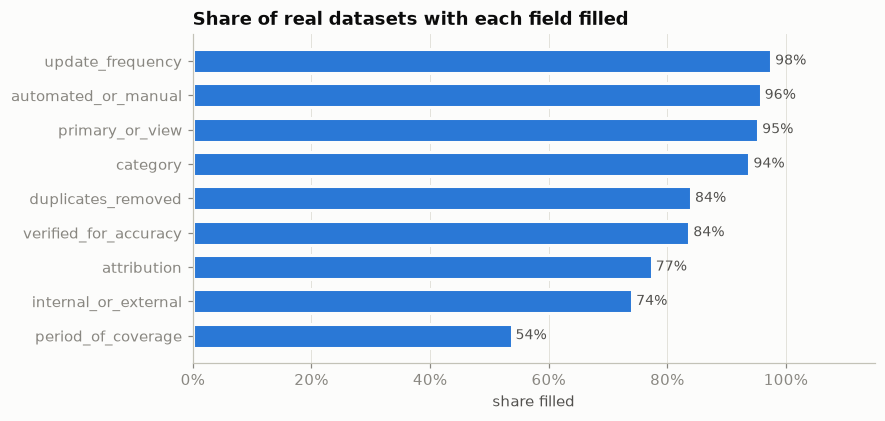

In [13]:
fields = ["category", "update_frequency", "automated_or_manual", "internal_or_external",
          "primary_or_view", "duplicates_removed", "verified_for_accuracy",
          "period_of_coverage", "attribution"]
fill = real[fields].notna().mean().sort_values(ascending=False)
hbar(fill, "Share of real datasets with each field filled", "share filled", fmt="{:.0%}")
plt.gca().set_xlim(0, 1.15)
plt.gca().xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
display(pd.DataFrame({
    "verified_for_accuracy": real.verified_for_accuracy.fillna("(not set)").value_counts(),
    "duplicates_removed": real.duplicates_removed.fillna("(not set)").value_counts(),
}))

## 8. Findings (snapshot 2026-10-02)

Numbers below are from the run committed with this notebook; re-running on a later
snapshot will change them.

1. **Series collapse matters most for a few categories.** 2088 assets → 1421 real
   datasets → 920 with each series counted once. Speed Check Sign (309 datasets, one per
   sign) is most of that cut: Vehicle Speed drops from 317 to 8 units; Census from 210
   to 113. Similarity work (M3) should default to the series-once view.
2. **Surveys is the largest category either way** (338 datasets, 310 units) and the
   widest: median 36 columns, and all ten widest datasets (up to 239 columns) are
   surveys — mostly one-off Edmonton Insight Community results, not series.
3. **Most of the catalogue is dormant.** Median unit is 8.6 years old and its data last
   changed 5.7 years ago; 525 of 920 units haven't changed in 5+ years, and 755 real
   datasets (53%) are labelled "Not Updated (Historical Only)". Only 196 units changed
   in the last 30 days.
4. **Fast schedules are kept; slow ones often aren't.** Daily 93% and Weekly 92% on
   schedule, but Monthly 58% and Annually 55%; 79 of the 534 datasets claiming a
   schedule are behind. Only 3 "Historical Only" datasets changed in the last 30 days
   (one is titled "Deprecated – …").
5. **"Automated" mostly means live**: 424 of 605 automated datasets changed within 14
   days vs 10 of 756 manual. Of the 181 automated-but-quiet ones, 107 are also
   "Historical Only" — feeds that were switched off without the flag being updated.
6. **Licence:** 1235 City, 132 third-party, 54 unknown (M1c class). 321 real datasets
   (23%) have no attribution; attribution text has spelling variants.
7. **Self-reported quality flags carry little signal:** "Verified for Accuracy" is Yes
   on 1176 and No on just 14; the rest are unset.
8. **Time coverage can't come from metadata alone:** "Period of Coverage" is filled on
   54% of real datasets and is free text ("2015", "Aug 1, 2019 onward", "Current").
   Measured coverage (Q1) and size need the column-statistics pull.

Caveat for 3–5: `data_updated_at` can move on a re-ingest without any change in the
rows; weekly snapshots plus row counts would separate the two.